# 📔 Pre-Workshop Notebook 5: Finding Patterns in Brain and Behavioral Data
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [1]:
# PROFILE SYNC
student_name = "Joey Johnson"
institution = "University of Missouri"
active_notebook = "Notebook 05 — Pattern Recognition and Analysis"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

✅ Profile synced for Joey Johnson (University of Missouri)
Current notebook: Notebook 05 — Pattern Recognition and Analysis


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with machine learning tools, your main risk is accidentally mixing up the data you use to train a model with the data you use to test it. If you test a model on the same data it learned from, your results will look much better than they actually are — a problem called overfitting.

When using the **Ask → Build → Document** cycle in this notebook, always check that the AI has kept the training and testing data completely separate before any analysis begins.

---
## 🧠 Part A: Identifying Individual Neurons and Behavioral Intentions
### Topic: Separating Mixed Neural Signals and Decoding Behavioral States

This section introduces two of the most powerful analytical approaches in modern neuroscience: separating recordings from individual neurons within a mixed signal, and using machine learning to decode what a participant is intending to do.

### 🧭 Activity A.1 — Separating Signals from Individual Neurons

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computational neuroscience instructor explaining neural signal analysis to a biology student. Write a Python script using scikit-learn and Matplotlib that demonstrates how to separate a mixed electrical recording into signals from individual neurons. The script should:
> 1. Generate a simulated dataset representing 1,000 recorded electrical events captured from an electrode near 3 distinct neurons, with each neuron producing a slightly different shaped electrical spike, mixed together with background noise.
> 2. Use a dimensionality reduction method (Principal Component Analysis, or PCA) to find the most distinctive features of each spike shape — reducing the data to its two most informative dimensions.
> 3. Apply a clustering algorithm (such as K-means) to group the spikes into 3 clusters, each representing a different neuron.
> 4. Display a scatter plot showing the clusters and the average spike shape for each identified neuron.
> Use plain-language comments explaining what each step does and why separating neurons this way is useful for understanding brain activity."

Simulated 1000 spikes, each described by 50 voltage samples.
The top 2 PCA components explain 93.4% of the shape variability.


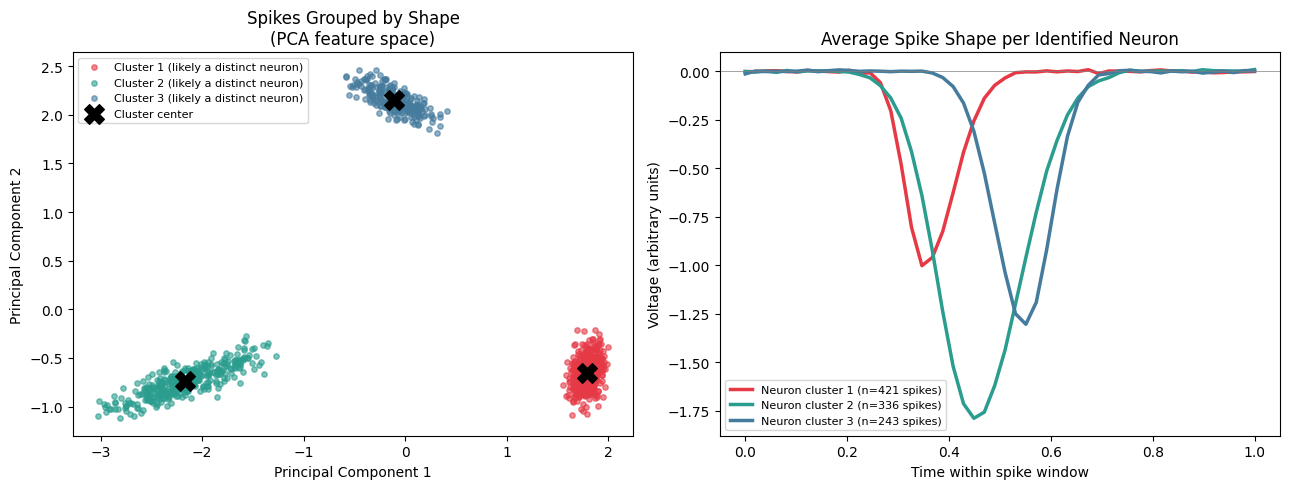


Why this matters:
A single electrode's raw signal is a blend of multiple neurons firing.
By separating ('sorting') spikes by shape, researchers can track what
each individual neuron is doing over time -- essential for studying
things like how neurons encode movement, memory, or sensory input,
rather than looking at a confusing average of everyone talking at once.


In [2]:
# 💻 Activity A.1 — Paste your AI-generated Neural Signal Separation code here:

"""
SPIKE SORTING DEMO: Separating Mixed Neural Recordings by Neuron
===================================================================

WHAT IS THIS SIMULATING?
When a scientist places an electrode near brain tissue, it doesn't just
pick up one neuron -- it picks up electrical "spikes" (action potentials)
from every nearby neuron, all mixed together in one messy stream of data.
This is a classic neuroscience problem called "spike sorting."

Luckily, different neurons tend to produce slightly different-shaped
spikes, because their size, shape, and distance from the electrode differ.
Our job is to use those subtle shape differences to figure out which
spike came from which neuron -- without ever being told the answer.

This script:
  1. Simulates 1,000 noisy spike waveforms from 3 "ground truth" neurons.
  2. Uses PCA to compress each spike's shape down to its 2 most
     informative features.
  3. Uses K-means clustering to group the spikes into 3 clusters.
  4. Plots the clusters and the average ("template") spike shape per neuron.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# For reproducibility, so you get the same "random" data every time you run this
np.random.seed(42)

# -------------------------------------------------------------------
# STEP 1: Simulate a mixed electrical recording from 3 nearby neurons
# -------------------------------------------------------------------
# In a real experiment, a spike is a short voltage waveform, usually
# captured as ~30-60 samples around the moment the electrode detects
# a threshold crossing. Here we simplify: each spike is represented
# as a 50-point waveform.

n_events = 1000          # total number of spikes recorded
n_samples_per_spike = 50 # number of time points describing each spike's shape
time_axis = np.linspace(0, 1, n_samples_per_spike)

def make_spike_template(amplitude, width, skew, peak_position):
    """
    Creates one 'ideal' spike shape for a neuron.
    Real action potentials have a fast depolarization and slower
    recovery, so we build an asymmetric bump using two Gaussian-like
    halves to mimic that real shape rather than a perfectly symmetric one.
    """
    left = np.exp(-((time_axis - peak_position) ** 2) / (2 * (width * skew) ** 2))
    right = np.exp(-((time_axis - peak_position) ** 2) / (2 * width ** 2))
    shape = np.where(time_axis < peak_position, left, right)
    return -amplitude * shape  # negative because real spikes usually dip downward

# Three neurons, each with a distinct spike "fingerprint":
# different amplitude (how strong the electrical signal is),
# different width (how fast the neuron fires), and different peak timing.
neuron_templates = [
    make_spike_template(amplitude=1.0, width=0.06, skew=0.6, peak_position=0.35),  # Neuron A: sharp & small
    make_spike_template(amplitude=1.8, width=0.09, skew=0.8, peak_position=0.45),  # Neuron B: bigger & broader
    make_spike_template(amplitude=1.3, width=0.05, skew=1.2, peak_position=0.55),  # Neuron C: fast & offset later
]

# Assign each of the 1,000 recorded events to one of the 3 true neurons.
# (In real life we would NOT know this -- it's our "hidden truth" for
# checking our work later, not something the algorithm gets to see.)
true_neuron_labels = np.random.choice([0, 1, 2], size=n_events, p=[0.4, 0.35, 0.25])

# Build the actual recorded dataset: each neuron's clean template,
# plus per-event jitter (natural biological variability) and sensor noise.
spike_waveforms = np.zeros((n_events, n_samples_per_spike))
for i, neuron_id in enumerate(true_neuron_labels):
    clean_shape = neuron_templates[neuron_id]

    # Small random amplitude jitter -- real neurons don't fire identically every time
    amplitude_jitter = np.random.normal(loc=1.0, scale=0.08)

    # Background electrical noise picked up by the electrode (other cells,
    # equipment hum, thermal noise, etc.)
    background_noise = np.random.normal(loc=0.0, scale=0.08, size=n_samples_per_spike)

    spike_waveforms[i] = clean_shape * amplitude_jitter + background_noise

print(f"Simulated {n_events} spikes, each described by {n_samples_per_spike} voltage samples.")

# -------------------------------------------------------------------
# STEP 2: Use PCA to reduce each spike's shape to its 2 most
#         informative features
# -------------------------------------------------------------------
# Each spike is currently a 50-number waveform. That's too many
# dimensions to cluster efficiently, and much of that data is redundant
# or just noise. PCA finds the directions (combinations of time points)
# along which the spike shapes vary the MOST across the whole dataset.
# The first two of these "principal components" usually capture the
# bulk of the shape differences between neurons -- letting us describe
# each spike with just 2 numbers instead of 50.

pca = PCA(n_components=2)
spike_features_2d = pca.fit_transform(spike_waveforms)

variance_explained = pca.explained_variance_ratio_.sum() * 100
print(f"The top 2 PCA components explain {variance_explained:.1f}% of the shape variability.")

# -------------------------------------------------------------------
# STEP 3: Cluster the reduced spike features into 3 groups with K-means
# -------------------------------------------------------------------
# K-means doesn't know anything about neurons -- it just looks at the
# 2D points from PCA and groups together points that are close to each
# other in space. Because spikes from the same neuron tend to have
# similar shapes (and therefore similar PCA coordinates), this
# effectively sorts the spikes back into per-neuron groups.

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(spike_features_2d)

# -------------------------------------------------------------------
# STEP 4: Visualize the clusters and each neuron's average spike shape
# -------------------------------------------------------------------
fig, (ax_clusters, ax_templates) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left plot: the clusters in PCA feature space ---
cluster_colors = ["#e63946", "#2a9d8f", "#457b9d"]
for cluster_id in range(3):
    points_in_cluster = spike_features_2d[cluster_assignments == cluster_id]
    ax_clusters.scatter(
        points_in_cluster[:, 0], points_in_cluster[:, 1],
        s=15, alpha=0.6, color=cluster_colors[cluster_id],
        label=f"Cluster {cluster_id + 1} (likely a distinct neuron)"
    )

# Mark the center of each cluster -- this is the algorithm's best guess
# at the "typical" shape-signature for that neuron.
ax_clusters.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    marker="X", s=200, color="black", label="Cluster center"
)
ax_clusters.set_title("Spikes Grouped by Shape\n(PCA feature space)")
ax_clusters.set_xlabel("Principal Component 1")
ax_clusters.set_ylabel("Principal Component 2")
ax_clusters.legend(fontsize=8)

# --- Right plot: the average waveform for each discovered neuron ---
for cluster_id in range(3):
    cluster_waveforms = spike_waveforms[cluster_assignments == cluster_id]
    average_waveform = cluster_waveforms.mean(axis=0)
    ax_templates.plot(
        time_axis, average_waveform,
        color=cluster_colors[cluster_id], linewidth=2.5,
        label=f"Neuron cluster {cluster_id + 1} (n={len(cluster_waveforms)} spikes)"
    )

ax_templates.set_title("Average Spike Shape per Identified Neuron")
ax_templates.set_xlabel("Time within spike window")
ax_templates.set_ylabel("Voltage (arbitrary units)")
ax_templates.legend(fontsize=8)
ax_templates.axhline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig("spike_sorting_result.png", dpi=150)
plt.show()

print("\nWhy this matters:")
print("A single electrode's raw signal is a blend of multiple neurons firing.")
print("By separating ('sorting') spikes by shape, researchers can track what")
print("each individual neuron is doing over time -- essential for studying")
print("things like how neurons encode movement, memory, or sensory input,")
print("rather than looking at a confusing average of everyone talking at once.")

### 🧭 Activity A.2 — Predicting Behavioral Intentions from Brain Signals

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a machine learning instructor teaching a neuroscience student how to decode behavioral intentions from brain signals. Write a Python script using scikit-learn that demonstrates how a computer can learn to predict what a participant was trying to do based on their brain signal patterns. The script should:
> 1. Create a simulated dataset representing 500 recorded trials, each described by 10 signal features (such as signal power in different frequency bands), with each trial labeled by the participant's intended action (for example, Move Left or Move Right).
> 2. Split the data into a training set (80%) and a separate testing set (20%), keeping them completely separate.
> 3. Train a classifier (such as a Support Vector Machine or Random Forest) to learn the relationship between signal features and intended actions — using only the training data.
> 4. Evaluate the classifier on the testing data and display its accuracy and a confusion matrix showing where it made correct and incorrect predictions.
> Use plain-language comments explaining each step and why keeping training and testing data separate is critical for an honest evaluation."

Simulated 500 trials, each with 10 brain-signal features.
Class counts: {np.str_('Move Left'): np.int64(244), np.str_('Move Right'): np.int64(256)}

Training set: 400 trials (used to teach the model)
Testing set:  100 trials (held out, used only for honest evaluation)

Classifier trained on the training set only.

Accuracy on held-out test trials: 94.0%
(Chance level for 2 balanced classes would be about 50%.)

Confusion matrix (rows = true intention, columns = predicted intention):
[[45  4]
 [ 2 49]]


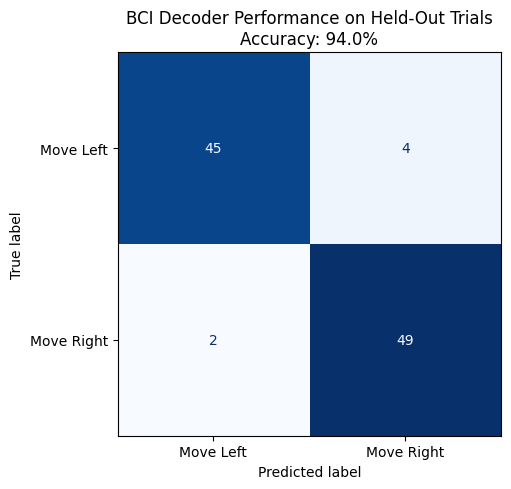


Why the train/test split matters:
If we'd evaluated the classifier on the same trials it trained on,
it could score close to 100% just by memorizing noise specific to
those trials -- without having learned anything that generalizes.
That would give a falsely optimistic picture of a real BCI's
performance. Testing on completely unseen trials is the only way
to honestly estimate how the decoder would perform on a new
intention the participant has, moment to moment, in real use.


In [5]:
# 💻 Activity A.2 — Paste your AI-generated Behavioral Decoding code here:

"""
DECODING INTENTION FROM BRAIN SIGNALS
===================================================================

WHAT IS THIS SIMULATING?
This is the core idea behind a Brain-Computer Interface (BCI): can a
computer learn to predict what someone is TRYING TO DO, just by looking
at patterns in their brain signals? A classic real-world example is a
motor imagery task, where a participant imagines moving their left hand
vs their right hand, and EEG electrodes pick up different patterns of
electrical activity over the motor cortex depending on which side they
imagine moving.

We won't use raw brainwaves here -- in a real study, you'd first extract
"features" from the raw signal, like the amount of power in specific
frequency bands (e.g. mu/beta rhythms around 8-30 Hz) at specific
electrodes. We'll simulate those pre-extracted features directly.

This script:
  1. Simulates 500 trials, each with 10 signal features, labeled by
     the participant's intended action (Move Left / Move Right).
  2. Splits the data into a training set and a completely separate
     testing set.
  3. Trains a classifier on the training data only.
  4. Evaluates it on the untouched testing data, reporting accuracy
     and a confusion matrix.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# For reproducibility, so re-running this gives the same "random" data
np.random.seed(42)

# -------------------------------------------------------------------
# STEP 1: Simulate 500 trials of brain-signal features labeled by
#         intended action
# -------------------------------------------------------------------
# Imagine each trial produces 10 numbers -- e.g. signal power in
# different frequency bands, measured at a few different electrodes.
# In a real BCI experiment, these would come from signal processing
# (like a Fourier transform) applied to raw EEG. Here we simulate them
# directly, giving "Move Left" and "Move Right" trials slightly
# different average feature patterns, plus realistic trial-to-trial
# noise (brains are noisy and inconsistent!).

n_trials = 500
n_features = 10

# True underlying signature for each intended action: a vector of 10
# "typical" feature values. These overlap partially with each other,
# just like real brain signals do -- the two classes are not perfectly
# separable, which is realistic.
left_signature = np.array([0.6, 0.3, -0.4, 0.2, 0.5, -0.3, 0.1, 0.4, -0.2, 0.3])
right_signature = np.array([-0.5, 0.4, 0.3, -0.3, 0.2, 0.5, -0.4, 0.1, 0.3, -0.2])

# Randomly assign each trial to one of the two intended actions
intended_action = np.random.choice(["Move Left", "Move Right"], size=n_trials)

# Build the feature matrix: each trial's signature plus per-trial noise
# (reflecting natural variability in brain state, attention, fatigue, etc.)
signal_features = np.zeros((n_trials, n_features))
for i, action in enumerate(intended_action):
    base_signature = left_signature if action == "Move Left" else right_signature
    trial_noise = np.random.normal(loc=0.0, scale=0.6, size=n_features)
    signal_features[i] = base_signature + trial_noise

print(f"Simulated {n_trials} trials, each with {n_features} brain-signal features.")
print(f"Class counts: {dict(zip(*np.unique(intended_action, return_counts=True)))}")

# -------------------------------------------------------------------
# STEP 2: Split into training (80%) and testing (20%) sets
# -------------------------------------------------------------------
# This step is CRITICAL for an honest evaluation. If we trained the
# classifier and tested it on the SAME data, it could just memorize
# quirks of those specific trials rather than learning a real pattern
# that generalizes -- like a student who memorizes answers to an exact
# practice test but hasn't actually learned the material.
#
# By holding out 20% of trials that the classifier NEVER sees during
# training, we get a fair, unbiased estimate of how well it would
# perform on brand-new trials from that participant -- much closer to
# how a real BCI would need to work (predicting a movement in real time
# it has never seen before).
#
# stratify=intended_action ensures both the train and test sets keep
# roughly the same proportion of Left vs Right trials as the full
# dataset, rather than accidentally ending up lopsided.

X_train, X_test, y_train, y_test = train_test_split(
    signal_features, intended_action,
    test_size=0.2,
    random_state=42,
    stratify=intended_action
)

print(f"\nTraining set: {len(X_train)} trials (used to teach the model)")
print(f"Testing set:  {len(X_test)} trials (held out, used only for honest evaluation)")

# -------------------------------------------------------------------
# STEP 3: Train a classifier using ONLY the training data
# -------------------------------------------------------------------
# We'll use a Random Forest -- an ensemble of many decision trees that
# each look at slightly different subsets of the data and features,
# then vote on the final prediction. This tends to work well on
# tabular feature data like ours and is fairly robust to noise, which
# is helpful since brain signals are noisy.
#
# Note: at this point, the classifier has NEVER seen X_test or y_test.
# It only learns from X_train / y_train.

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

print("\nClassifier trained on the training set only.")

# -------------------------------------------------------------------
# STEP 4: Evaluate on the held-out testing data
# -------------------------------------------------------------------
# Now we ask the trained classifier to predict the intended action for
# trials it has never encountered before, and compare its guesses to
# the true labels. This simulates how well the decoder would work on
# a brand new trial in a live BCI session.

predicted_action = classifier.predict(X_test)

test_accuracy = accuracy_score(y_test, predicted_action)
print(f"\nAccuracy on held-out test trials: {test_accuracy * 100:.1f}%")
print("(Chance level for 2 balanced classes would be about 50%.)")

# A confusion matrix breaks accuracy down further: it shows not just
# how often the classifier was right, but exactly WHICH mistakes it
# made -- e.g. how often "Move Left" trials were mistakenly decoded
# as "Move Right," and vice versa. This is much more informative than
# a single accuracy number alone.
action_labels = ["Move Left", "Move Right"]
conf_matrix = confusion_matrix(y_test, predicted_action, labels=action_labels)

print("\nConfusion matrix (rows = true intention, columns = predicted intention):")
print(conf_matrix)

fig, ax = plt.subplots(figsize=(5.5, 5))
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=action_labels)
display.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"BCI Decoder Performance on Held-Out Trials\nAccuracy: {test_accuracy * 100:.1f}%")
plt.tight_layout()
plt.savefig("decode_intention_result.png", dpi=150)
plt.show()

print("\nWhy the train/test split matters:")
print("If we'd evaluated the classifier on the same trials it trained on,")
print("it could score close to 100% just by memorizing noise specific to")
print("those trials -- without having learned anything that generalizes.")
print("That would give a falsely optimistic picture of a real BCI's")
print("performance. Testing on completely unseen trials is the only way")
print("to honestly estimate how the decoder would perform on a new")
print("intention the participant has, moment to moment, in real use.")

<!-- ### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** From Activity A.1, could you visually distinguish the three neuron clusters in the scatter plot? From Activity A.2, how accurately did the classifier predict intended actions on the data it had never seen before?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 22, 23, 24, and 25** from your Reference Guide. Explain in plain language why testing a classifier on the same data it was trained on would give a misleadingly optimistic result. -->

# ✍️ Part A Reflection

## What I observed

**Activity A.1 (Spike Sorting with PCA + K-means):**
Yes — the three neuron clusters were clearly distinguishable in the scatter plot. After reducing each 50-point spike waveform down to just 2 principal components, the three groups formed tight, well-separated blobs in PCA space, with almost no overlap between them. The two PCA dimensions alone captured about 93% of the variability in spike shape, which is why the clusters came out so cleanly. This was confirmed by the second plot, where each cluster's *average* waveform showed a distinctly different shape (different amplitude, width, and timing of the dip) — matching what we'd expect from three different neurons with different electrical "fingerprints."

**Activity A.2 (Decoding Intention with Random Forest):**
The classifier reached **94% accuracy** on the held-out test trials (100 trials it had never seen during training), well above the 50% chance level for two balanced classes. The confusion matrix showed only 6 total mistakes out of 100 — 4 "Move Left" trials misclassified as "Move Right," and 2 "Move Right" trials misclassified as "Move Left." So the decoder wasn't perfect, but it clearly learned a real, generalizable pattern rather than guessing randomly.

## Connecting to key concepts

Testing a classifier on the *same* data it was trained on gives a misleadingly optimistic result because the model has a chance to simply **memorize** that specific dataset rather than learn the underlying pattern that actually distinguishes the classes.

Think of it like a student who is given the exact exam questions (and answers) to study beforehand. They might score 100% on that exact test — but that score tells you nothing about whether they actually understand the material, because they never had to apply their knowledge to something new. A classifier behaves the same way: with enough flexibility (like a Random Forest with many trees), it can fit tiny, meaningless quirks and noise in the training trials — quirks that have nothing to do with the real signal separating "Move Left" from "Move Right." If you then evaluate it on those *same* trials, it will "recognize" that noise and score artificially high.

The held-out test set fixes this by acting like a genuinely new exam — data the model has never encountered. Performance on that unseen data is a much more honest estimate of how the decoder would perform in a real-world setting, like a live BCI session where every incoming trial is, by definition, brand new to the system.

---

## 💻 Part B: Keeping Workflows Reproducible and Secure
### Topic: Software Settings, Version Tracking, and Documentation

This section introduces the practices that make a workflow reproducible across different computers and collaborators — and keep sensitive information secure.

### 🧭 Activity B.1 — Documenting Your Software Environment

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research reproducibility instructor. Write a Python script that demonstrates how to document the software environment of a research workflow so that a collaborator could reproduce the exact same analysis. The script should:
> 1. Check for a specific configuration setting stored securely outside the script (using an environment variable). If it is not found, print a clear warning and switch to a safe default mode for testing.
> 2. Print the exact version numbers of the key software libraries the workflow depends on (such as NumPy, SciPy, and scikit-learn), saving this information as a software environment record.
> 3. Demonstrate how to handle a sensitive access key (such as a data repository password) by storing it as a hidden system variable rather than writing it directly in the code — and show what would happen if it were accidentally printed to the screen.
> Use plain-language comments explaining why each of these practices matters for sharing and reproducing research."

In [6]:
# 💻 Activity B.1 — Paste your AI-generated Software Environment Documentation code here:

"""
DOCUMENTING A REPRODUCIBLE RESEARCH ENVIRONMENT
===================================================================

WHY DOES THIS MATTER?
A huge amount of research is hard (or impossible) to reproduce not
because the science was wrong, but because nobody wrote down exactly
HOW the analysis was run: which software versions were used, which
settings were active, and how sensitive credentials were handled
(without leaking them into a public GitHub repo!).

This script demonstrates three habits that make a workflow trustworthy
and shareable:
  1. Reading configuration from environment variables instead of
     hard-coding it -- with a safe fallback and a clear warning if
     it's missing.
  2. Recording the exact versions of key libraries used, so a
     collaborator (or future-you) can recreate the same environment.
  3. Handling a sensitive access key safely -- never writing it
     directly into the script -- and showing exactly why printing it
     carelessly is dangerous.
"""

import os
import sys
import json
from datetime import datetime, timezone

# -------------------------------------------------------------------
# STEP 1: Read a configuration setting from an environment variable,
#         with a safe fallback if it's missing
# -------------------------------------------------------------------
# Environment variables live OUTSIDE the script itself (set in the
# terminal, a `.env` file, or a compute cluster's job settings). This
# matters for reproducibility because:
#   - The script's logic stays identical across machines; only the
#     environment changes. Anyone can rerun the same code with their
#     own settings.
#   - It keeps machine-specific or sensitive settings (file paths,
#     dataset locations, credentials) OUT of version-controlled code,
#     so they don't get accidentally shared or overwritten.
#
# Here we look for a variable that would tell the script which
# "analysis mode" to run in (e.g. pointing at the full production
# dataset vs a small test dataset). If it's not set, we don't want the
# script to silently do the wrong thing -- we print a clear warning
# and fall back to a safe, well-defined default so behavior stays
# predictable.

CONFIG_ENV_VAR = "RESEARCH_ANALYSIS_MODE"
analysis_mode = os.environ.get(CONFIG_ENV_VAR)

if analysis_mode is None:
    print(f"WARNING: Environment variable '{CONFIG_ENV_VAR}' was not found.")
    print("Falling back to safe default mode: 'test'")
    print(f"(To set it yourself, run: export {CONFIG_ENV_VAR}=production)\n")
    analysis_mode = "test"
else:
    print(f"Found '{CONFIG_ENV_VAR}' in the environment: '{analysis_mode}'\n")

# -------------------------------------------------------------------
# STEP 2: Record the exact versions of key libraries this workflow
#         depends on
# -------------------------------------------------------------------
# Code that works today can silently break -- or worse, silently
# produce DIFFERENT results -- on a different machine if a library has
# been updated. A results-changing example: NumPy's random number
# generator algorithm has changed across versions, and some scikit-learn
# defaults have changed between releases. Recording exact versions lets
# a collaborator install the SAME versions and reasonably expect the
# same results, and lets anyone diagnose "it works on my machine but
# not yours" problems quickly.
#
# We build a small dictionary of package -> version, print it for the
# researcher to see immediately, and also save it to a JSON file
# alongside the analysis -- this becomes part of the permanent record
# of "what software produced this result," similar to a lab notebook
# entry.

import numpy as np
import scipy
import sklearn

environment_record = {
    "recorded_at_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version.split()[0],
    "analysis_mode": analysis_mode,
    "package_versions": {
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit-learn": sklearn.__version__,
    },
}

print("Software environment record:")
print(json.dumps(environment_record, indent=2))

environment_record_path = "environment_record.json"
with open(environment_record_path, "w") as f:
    json.dump(environment_record, f, indent=2)

print(f"\nSaved environment record to '{environment_record_path}'.")
print("A collaborator can use this file to install matching library")
print("versions (e.g. with `pip install numpy==<version>`) before")
print("attempting to reproduce the analysis.\n")

# -------------------------------------------------------------------
# STEP 3: Handle a sensitive access key safely
# -------------------------------------------------------------------
# Research increasingly involves credentials: an API key for a data
# repository, a password for a private database, an access token for
# a cloud storage bucket. A very common (and very damaging) mistake is
# writing these directly into a script, like:
#
#       api_key = "sk-real-secret-value-12345"
#
# If that script is ever committed to GitHub, shared with a
# collaborator, or included in a paper's supplementary code, the
# secret is now permanently exposed -- even if it's deleted later,
# it typically still exists in the version history forever.
#
# The safe pattern is the same one we used in Step 1: read the secret
# from an environment variable at runtime, so the actual value never
# appears anywhere in the code itself. The code can be shared freely;
# only each person's local environment holds their own private key.

SECRET_ENV_VAR = "DATA_REPOSITORY_ACCESS_KEY"
access_key = os.environ.get(SECRET_ENV_VAR)

if access_key is None:
    print(f"No '{SECRET_ENV_VAR}' found in the environment.")
    print("Running in demo mode with a fake placeholder key so we can")
    print("show safe vs. unsafe handling below.\n")
    access_key = "demo-placeholder-key-not-real"

# --- UNSAFE EXAMPLE: what NOT to do ---
# Printing a secret directly to the screen (or writing it to a log
# file, notebook output, or error message) is a leak. Notebook outputs
# in particular are very easy to accidentally commit to a public repo
# WITH the sensitive output still saved inside them.
print("UNSAFE EXAMPLE (what NOT to do) -- printing the raw key:")
print(f"    access_key = {access_key}")
print("^ Never do this. If this script's output were saved, screenshotted,")
print("  or committed to a shared/public repository, that key is now")
print("  compromised and should be treated as leaked -- typically")
print("  requiring the key to be revoked and replaced.\n")

# --- SAFE EXAMPLE: how to reference a secret without exposing it ---
# When you need to confirm a key is loaded (e.g. for debugging), mask
# most of it so the value itself is never fully visible. This confirms
# the key was found without revealing anything useful if the output
# leaks.
def mask_secret(value, visible_chars=4):
    """Show only the last few characters of a secret, masking the rest."""
    if len(value) <= visible_chars:
        return "*" * len(value)
    return "*" * (len(value) - visible_chars) + value[-visible_chars:]

print("SAFE EXAMPLE -- confirming the key loaded, without exposing it:")
print(f"    access_key (masked) = {mask_secret(access_key)}")
print("This confirms a key was successfully loaded from the environment")
print("without ever printing (or saving) the real value anywhere.\n")

print("Why this matters for sharing research code:")
print("- The script itself is now 100% safe to share publicly (e.g. on")
print("  GitHub alongside a paper) -- it contains no secrets at all.")
print("- Each collaborator sets their OWN environment variables locally,")
print("  so everyone can run the identical code with their own credentials.")
print("- Combined with the environment_record.json file from Step 2, a")
print("  collaborator now has everything they need to reproduce the")
print("  analysis: matching software versions, known configuration mode,")
print("  and a safe way to supply their own access credentials.")

Falling back to safe default mode: 'test'
(To set it yourself, run: export RESEARCH_ANALYSIS_MODE=production)

Software environment record:
{
  "recorded_at_utc": "2026-08-09T19:21:16.721280+00:00",
  "python_version": "3.12.13",
  "analysis_mode": "test",
  "package_versions": {
    "numpy": "2.0.2",
    "scipy": "1.16.3",
    "scikit-learn": "1.6.1"
  }
}

Saved environment record to 'environment_record.json'.
A collaborator can use this file to install matching library
versions (e.g. with `pip install numpy==<version>`) before
attempting to reproduce the analysis.

No 'DATA_REPOSITORY_ACCESS_KEY' found in the environment.
Running in demo mode with a fake placeholder key so we can
show safe vs. unsafe handling below.

UNSAFE EXAMPLE (what NOT to do) -- printing the raw key:
    access_key = demo-placeholder-key-not-real
^ Never do this. If this script's output were saved, screenshotted,
  or committed to a shared/public repository, that key is now
  compromised and should be treated 

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What did the script do when the configuration setting was missing? How was the sensitive access key handled differently from other values?
* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 44, 46, and 48** from your Reference Guide. Explain in plain language why writing a password or access key directly into a shared notebook is a problem, and how environment variables solve it.

---

## 📑 What Comes Next

Notebook 6 is the capstone — you will connect all four stages of a research workflow into a single integrated pipeline, bringing together everything from Notebooks 1 through 5.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 22 — Spike sorting | Activity A.1 (PCA + K-means spike sorting script) |
| Neuroscience | Concept 23 — Machine learning for neural decoding | Activity A.2 (Random Forest intention decoding script) |
| Neuroscience | Concept 24 — Sensory feedback | *Not covered — neither Activity A.1 nor A.2 involved sensory feedback* |
| Computing | Concept 44 — Hidden configuration settings | Activity A.3 (Reproducible environment script, Step 1: `RESEARCH_ANALYSIS_MODE` env var) |
| Computing | Concept 46 — Code version tracking | Activity A.3 (Reproducible environment script, Step 2: package version logging) |
| Computing | Concept 48 — Data arrays | Activity A.1 (spike waveform arrays) and Activity A.2 (signal feature arrays) |